# Monte Carlo Simulation

In this notebook, we demonstrate option pricing using **Monte Carlo (MC) simulation**.

We consider a **European call option** and evaluate the convergence of the MC estimator using different numbers of simulation paths, ranging from **500 to 500,000**. We examine three scenarios:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We compare the Monte Carlo results with the analytical price from the **Black-Scholes-Merton (BSM) model**.
The results show that the MC estimates, together with their **95% confidence intervals**, are consistent with the BSM price. Among the three approaches, the **control variate method** provides the most precise estimates by significantly reducing the estimator variance.

---
## Import Packages and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from binomial_model import price_option_tree
from monte_carlo import price_option_mc, price_american_lsmc

## 1. European Call option

We price a **European call option** using **Monte Carlo (MC) simulation** with different numbers of paths ranging from **500 to 500,000**.

We consider three approaches:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We visualize the estimated option prices and compare them with the analytical solution from the **Black-Scholes-Merton (BSM) model**, shown as the red horizontal dashed line in the plot.

The Monte Carlo estimates converge to the BSM price as the number of simulation paths increases. The **95% confidence intervals** illustrate the statistical uncertainty of the estimator. Among the three approaches, the **control variate method provides the most precise estimates**, as it significantly reduces the variance of the Monte Carlo estimator.

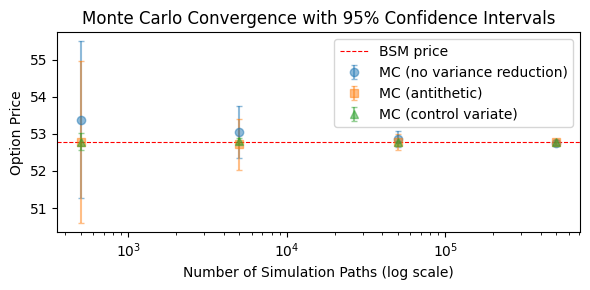

In [2]:
# parameters
seed = None

s = 100
k = 50
r = 0.1
sigma = 0.25
T = 1
q = 0.02

option_type = 'call'
exercise_style = 'European'

N_paths = np.asarray([500, 5000, 50000, 500000])

price1, price2, price3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))
std1, std2, std3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))

for i, n_paths in enumerate(N_paths):
    # no variance reduction
    price1[i], std1[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=False, seed=seed)
    # antithetic variates
    price2[i], std2[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=True, control_variate=False, seed=seed)
    # control variate
    price3[i], std3[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=True, seed=seed)

price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

# 95% confidence level
ci1 = 1.96*std1
ci2 = 1.96*std2
ci3 = 1.96*std3

plt.figure(figsize=(6,3))

plt.errorbar(N_paths, price1, yerr=ci1, fmt='o', capsize=2, alpha=0.5,
             label='MC (no variance reduction)')

plt.errorbar(N_paths, price2, yerr=ci2, fmt='s', capsize=2, alpha=0.5,
             label='MC (antithetic)')

plt.errorbar(N_paths, price3, yerr=ci3, fmt='^', capsize=2, alpha=0.5,
             label='MC (control variate)')

plt.axhline(price_bsm, linestyle='--', color='red', linewidth=0.8,
            label='BSM price')

plt.xscale('log')

plt.xlabel('Number of Simulation Paths (log scale)')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence with 95% Confidence Intervals')
plt.legend()

plt.tight_layout()
plt.show()

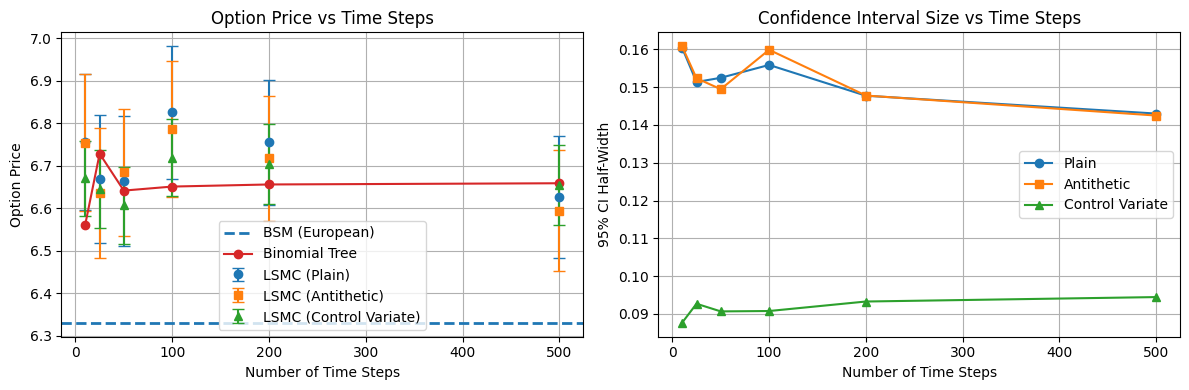

In [3]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

N_steps = [10, 25, 50, 100, 200, 500]
n_paths = 10000

# containers
price_tree = np.zeros(len(N_steps))

price_plain = np.zeros(len(N_steps))
stderr_plain = np.zeros(len(N_steps))

price_anti = np.zeros(len(N_steps))
stderr_anti = np.zeros(len(N_steps))

price_cv = np.zeros(len(N_steps))
stderr_cv = np.zeros(len(N_steps))

# baseline (European)
price_bsm = price_option_bsm(option_type, 'European', s, k, r, sigma, T, q)

for i, n_steps in enumerate(N_steps):

    # Binomial
    price_tree[i] = price_option_tree(
        option_type, exercise_style, s, k, r, sigma, T,
        N=n_steps, q=q, return_tree=False
    )

    # 1. Plain
    price_plain[i], stderr_plain[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=False, seed=42)

    # 2. Antithetic
    price_anti[i], stderr_anti[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
       n_steps=n_steps, n_paths=n_paths, antithetic=True, control_variate=False, seed=42)

    # 3. Control variate
    price_cv[i], stderr_cv[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=True, seed=42)

# 95% CI
ci_plain = 1.96 * stderr_plain
ci_anti = 1.96 * stderr_anti
ci_cv = 1.96 * stderr_cv


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# left panel: pricing
ax = axes[0]

# LSMC, plain
ax.errorbar(N_steps, price_plain, yerr=ci_plain,
            fmt='o', capsize=4, linestyle='none', label='LSMC (Plain)')

# LSMC, antithetic
ax.errorbar(N_steps, price_anti, yerr=ci_anti,
            fmt='s', capsize=4, linestyle='none', label='LSMC (Antithetic)')

# LSMC, control variate
ax.errorbar(N_steps, price_cv, yerr=ci_cv,
            fmt='^', capsize=4, linestyle='none', label='LSMC (Control Variate)')

# bsm
ax.axhline(y=price_bsm, linestyle='--', linewidth=2, label='BSM (European)')

# binomial
ax.plot(N_steps, price_tree, marker='o', linestyle='-', label='Binomial Tree')

ax.set_xlabel('Number of Time Steps')
ax.set_ylabel('Option Price')
ax.set_title('Option Price vs Time Steps')
ax.legend()
ax.grid(True)


# right: CI size
ax = axes[1]

ax.plot(N_steps, ci_plain, marker='o', linestyle='-', label='Plain')
ax.plot(N_steps, ci_anti, marker='s', linestyle='-', label='Antithetic')
ax.plot(N_steps, ci_cv, marker='^', linestyle='-', label='Control Variate')

ax.set_xlabel('Number of Time Steps')
ax.set_ylabel('95% CI Half-Width')
ax.set_title('Confidence Interval Size vs Time Steps')
ax.legend()
ax.grid(True)


plt.tight_layout()
plt.show()

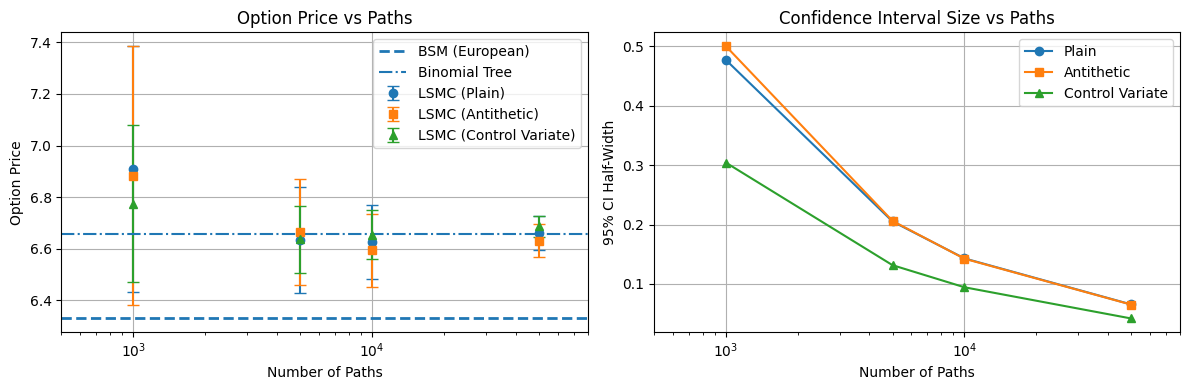

In [4]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

n_steps = 500
N_paths = [1000, 5000, 10000, 50000]

# containers
price_plain = np.zeros(len(N_paths))
stderr_plain = np.zeros(len(N_paths))

price_anti = np.zeros(len(N_paths))
stderr_anti = np.zeros(len(N_paths))

price_cv = np.zeros(len(N_paths))
stderr_cv = np.zeros(len(N_paths))

# baseline1 (European)
price_bsm = price_option_bsm(option_type, 'European', s, k, r, sigma, T, q)

# baseline2 (binomial)
price_tree = price_option_tree(
        option_type, exercise_style, s, k, r, sigma, T,
        N=n_steps, q=q, return_tree=False
    )

for i, n_paths in enumerate(N_paths):

    # 1. Plain
    price_plain[i], stderr_plain[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=False, seed=42)

    # 2. Antithetic
    price_anti[i], stderr_anti[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
       n_steps=n_steps, n_paths=n_paths, antithetic=True, control_variate=False, seed=42)

    # 3. Control variate
    price_cv[i], stderr_cv[i] = price_american_lsmc(option_type, s, k, r, sigma, T, q,
        n_steps=n_steps, n_paths=n_paths, antithetic=False, control_variate=True, seed=42)

# 95% CI
ci_plain = 1.96 * stderr_plain
ci_anti = 1.96 * stderr_anti
ci_cv = 1.96 * stderr_cv


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax in axes:
    ax.set_xscale('log')

# left panel: pricing
ax = axes[0]

# LSMC, plain
ax.errorbar(N_paths, price_plain, yerr=ci_plain,
            fmt='o', capsize=4, linestyle='none', label='LSMC (Plain)')

# LSMC, antithetic
ax.errorbar(N_paths, price_anti, yerr=ci_anti,
            fmt='s', capsize=4, linestyle='none', label='LSMC (Antithetic)')

# LSMC, control variate
ax.errorbar(N_paths, price_cv, yerr=ci_cv,
            fmt='^', capsize=4, linestyle='none', label='LSMC (Control Variate)')

# bsm
ax.axhline(y=price_bsm, linestyle='--', linewidth=2, label='BSM (European)')

# binomial
ax.axhline(y=price_tree, linestyle='-.', label='Binomial Tree')

ax.set_xlim(500, 80000)
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Option Price')
ax.set_title('Option Price vs Paths')
ax.legend()
ax.grid(True)


# right: CI size
ax = axes[1]

ax.plot(N_paths, ci_plain, marker='o', linestyle='-', label='Plain')
ax.plot(N_paths, ci_anti, marker='s', linestyle='-', label='Antithetic')
ax.plot(N_paths, ci_cv, marker='^', linestyle='-', label='Control Variate')
ax.set_xlim(500, 80000)

ax.set_xlabel('Number of Paths')
ax.set_ylabel('95% CI Half-Width')
ax.set_title('Confidence Interval Size vs Paths')

ax.legend()
ax.grid(True)


plt.tight_layout()
plt.show()

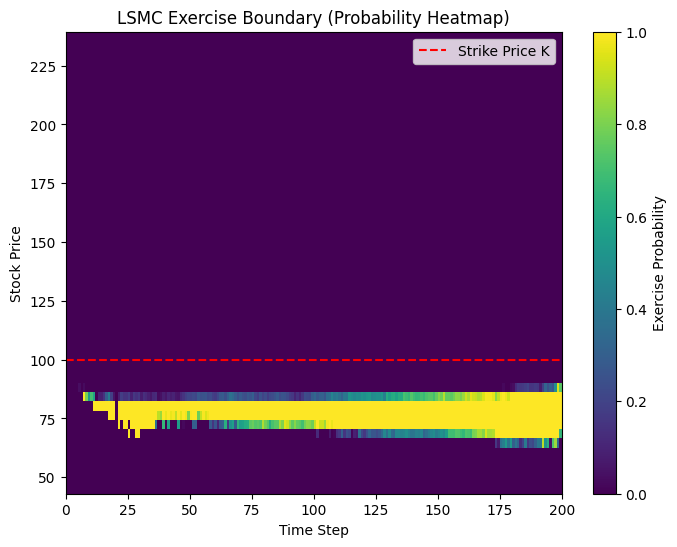

In [5]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

n_steps = 200
n_paths = 50000

price, std_err, exercise_matrix, stocks = price_american_lsmc(option_type, s, k, r, sigma, T, q, n_steps, n_paths, 
                                            antithetic=False, control_variate=True, seed=None, return_exercise=True)

n_bins = 50
S_min, S_max = stocks.min(), stocks.max()

bins = np.linspace(S_min, S_max, n_bins+1)

heatmap = np.zeros((n_bins, n_steps))
counts = np.zeros((n_bins, n_steps))

for t in range(1, n_steps):
    S_t = stocks[:, t]
    exercise_t = exercise_matrix[:, t]

    bin_idx = np.digitize(S_t, bins) - 1

    for i in range(n_paths):
        b = bin_idx[i]
        if 0 <= b < n_bins:
            heatmap[b, t] += exercise_t[i]
            counts[b, t] += 1

prob_exercise = np.divide(
    heatmap, counts,
    out=np.zeros_like(heatmap),
    where=counts > 0
)

plt.figure(figsize=(8, 6))

X = np.arange(n_steps + 1)  # time steps
Y = bins  # stock price bins

plt.pcolormesh(X, Y, prob_exercise, shading='auto', cmap='viridis')

plt.colorbar(label='Exercise Probability')

plt.axhline(k, color='red', linestyle='--', label='Strike Price K')

plt.xlabel('Time Step')
plt.ylabel('Stock Price')
plt.title('LSMC Exercise Boundary (Probability Heatmap)')

plt.legend()
plt.show()

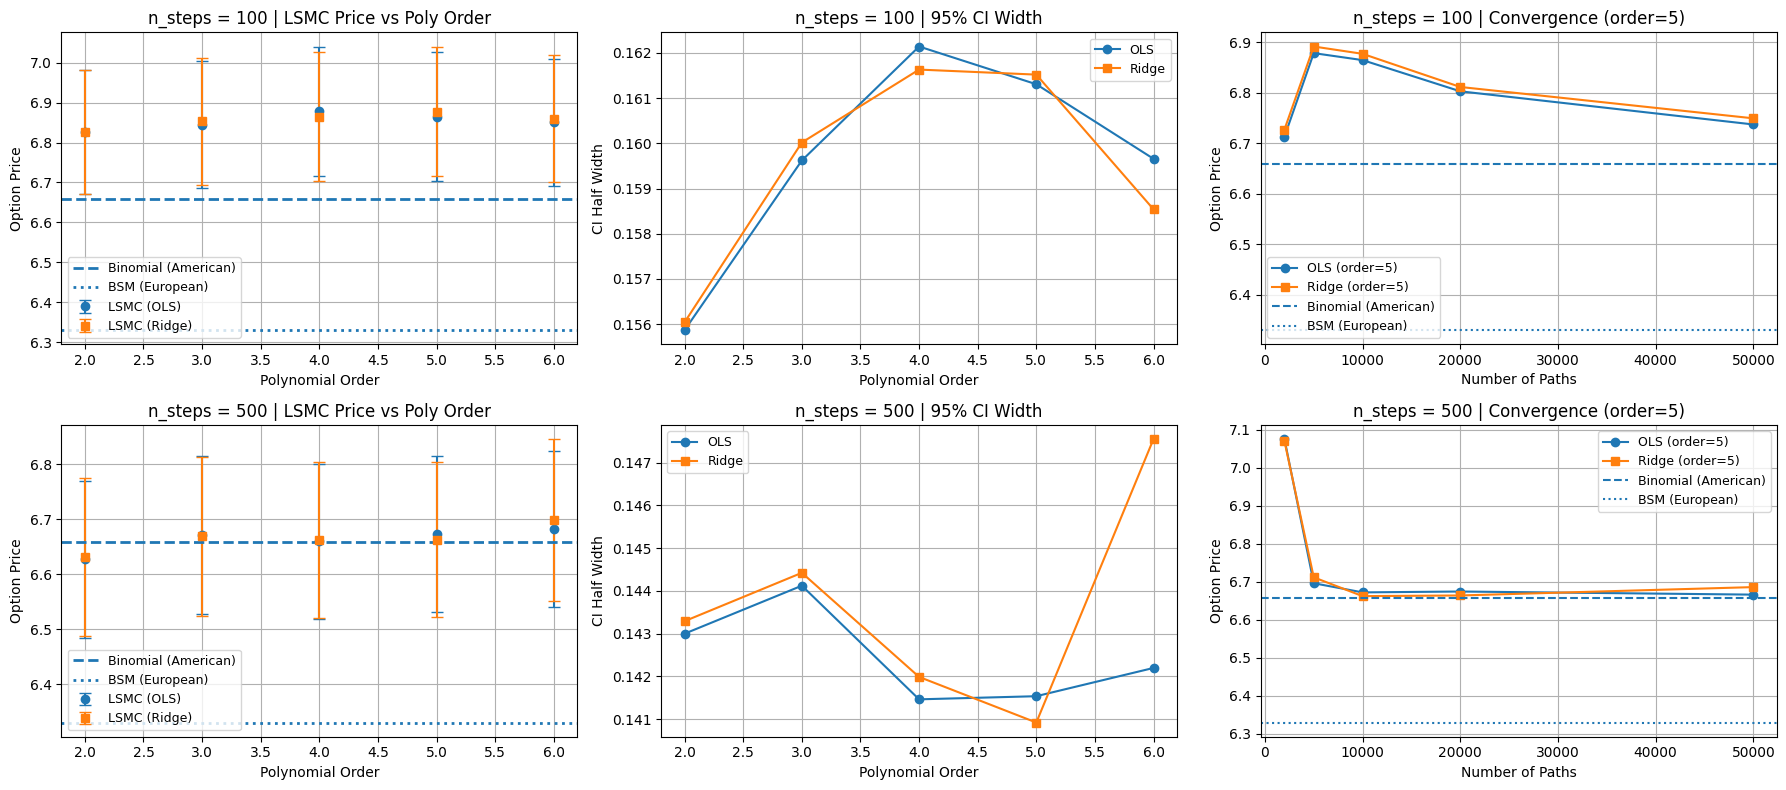

In [6]:
option_type = 'put'
exercise_style = 'American'

s = 100
k = 100
r = 0.05
sigma = 0.2
T = 1
q = 0.02

n_steps = 500
n_paths = 10000
poly_orders = [2, 3, 4, 5, 6]

# containers
price_ols = np.zeros(len(poly_orders))
stderr_ols = np.zeros(len(poly_orders))

price_ridge = np.zeros(len(poly_orders))
stderr_ridge = np.zeros(len(poly_orders))

# high-resolution binomial (American)
price_tree = price_option_tree(
    option_type, exercise_style, s, k, r, sigma, T,
    N=500, q=q, return_tree=False
)

# European BSM
price_bsm = price_option_bsm(option_type, 'European', s, k, r, sigma, T, q)

# run experiment
for i, order in enumerate(poly_orders):

    # OLS
    price_ols[i], stderr_ols[i] = price_american_lsmc(
        option_type, s, k, r, sigma, T, q,
        n_steps=n_steps,
        n_paths=n_paths,
        poly_order=order,
        regression="ols",
        seed=42
    )

    # Ridge
    price_ridge[i], stderr_ridge[i] = price_american_lsmc(
        option_type, s, k, r, sigma, T, q,
        n_steps=n_steps,
        n_paths=n_paths,
        poly_order=order,
        regression="ridge",
        ridge_alpha=1e-4,
        seed=42
    )

# 95% CI
ci_ols = 1.96 * stderr_ols
ci_ridge = 1.96 * stderr_ridge

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
n_steps_list = [100, 500]

for row_idx, n_step_val in enumerate(n_steps_list):

    # Run experiment for this n_steps
    price_ols = np.zeros(len(poly_orders))
    stderr_ols = np.zeros(len(poly_orders))

    price_ridge = np.zeros(len(poly_orders))
    stderr_ridge = np.zeros(len(poly_orders))

    # LSMC price for each polynomial order
    for i, order in enumerate(poly_orders):
        price_ols[i], stderr_ols[i] = price_american_lsmc(
            option_type, s, k, r, sigma, T, q,
            n_steps=n_step_val,
            n_paths=n_paths,
            poly_order=order,
            regression="ols",
            seed=42
        )

        price_ridge[i], stderr_ridge[i] = price_american_lsmc(
            option_type, s, k, r, sigma, T, q,
            n_steps=n_step_val,
            n_paths=n_paths,
            poly_order=order,
            regression="ridge",
            ridge_alpha=1e-4,
            seed=42
        )

    ci_ols = 1.96 * stderr_ols
    ci_ridge = 1.96 * stderr_ridge

    # Panel 1: LSMC Price vs Polynomial Order
    ax = axes[row_idx, 0]

    ax.errorbar(poly_orders, price_ols, yerr=ci_ols,
                fmt='o', capsize=4, label='LSMC (OLS)')
    ax.errorbar(poly_orders, price_ridge, yerr=ci_ridge,
                fmt='s', capsize=4, label='LSMC (Ridge)')
    ax.axhline(price_tree, linestyle='--', linewidth=2, label='Binomial (American)')
    ax.axhline(price_bsm, linestyle=':', linewidth=2, label='BSM (European)')

    ax.set_title(f'n_steps = {n_step_val} | LSMC Price vs Poly Order')
    ax.set_xlabel('Polynomial Order')
    ax.set_ylabel('Option Price')
    ax.legend(fontsize=9)
    ax.grid(True)

    # Panel 2: 95% CI Width
    ax = axes[row_idx, 1]

    ax.plot(poly_orders, ci_ols, marker='o', label='OLS')
    ax.plot(poly_orders, ci_ridge, marker='s', label='Ridge')

    ax.set_title(f'n_steps = {n_step_val} | 95% CI Width')
    ax.set_xlabel('Polynomial Order')
    ax.set_ylabel('CI Half Width')
    ax.legend(fontsize=9)
    ax.grid(True)

    # Panel 3: Convergence vs Number of Paths (order=5)
    ax = axes[row_idx, 2]

    path_grid = [2000, 5000, 10000, 20000, 50000]
    price_ols_paths = []
    price_ridge_paths = []

    for p in path_grid:
        price_tmp, _ = price_american_lsmc(
            option_type, s, k, r, sigma, T, q,
            n_steps=n_step_val,
            n_paths=p,
            poly_order=5,
            regression="ols",
            seed=42
        )
        price_ols_paths.append(price_tmp)

        price_tmp, _ = price_american_lsmc(
            option_type, s, k, r, sigma, T, q,
            n_steps=n_step_val,
            n_paths=p,
            poly_order=5,
            regression="ridge",
            ridge_alpha=1e-4,
            seed=42
        )
        price_ridge_paths.append(price_tmp)

    ax.plot(path_grid, price_ols_paths, marker='o', label='OLS (order=5)')
    ax.plot(path_grid, price_ridge_paths, marker='s', label='Ridge (order=5)')
    ax.axhline(price_tree, linestyle='--', label='Binomial (American)')
    ax.axhline(price_bsm, linestyle=':', label='BSM (European)')

    ax.set_title(f'n_steps = {n_step_val} | Convergence (order=5)')
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Option Price')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()